### modeling_2nd_recent

Recent-flow logistic modeling notebook with reduced-core feature evaluation.

In [1]:
import pandas as pd
import numpy as np

df23 = pd.read_csv("model_df_2023.csv")
df24 = pd.read_csv("model_df_2024.csv")
df25 = pd.read_csv("model_df_2025.csv")

df = pd.concat([df23, df24, df25], axis=0, ignore_index=True)

print(df.shape)
print(df.head())
print(df.columns.tolist())

(2114, 70)
    game_id            game_date  season  home_team_code  away_team_code  \
0  20230711  2023-03-23 04:00:00    2023           10001            1001   
1  20230712  2023-03-23 04:00:00    2023           12001            5002   
2  20230716  2023-03-24 04:00:00    2023           10001            1001   
3  20230717  2023-03-24 04:00:00    2023           12001            5002   
4  20230718  2023-03-24 04:00:00    2023            7002            6002   

   stadium_code  home_sp_id  away_sp_id home_sp_name away_sp_name  ...  \
0          1003       14674       11404          繹먃??됱겫          ?館釉섆빳?  ...   
1          2002       11318       14780          ?袁⑷맒獄?         揶쏅벤?싮넫? ...   
2          1003       11379       14613          筌ㅼ뮇???         ??됱몖?? ...   
3          2002       15542       13102           ?癒?퐣          繹먃?怨?  ...   
4          4001       10610       13061          ?貫???          ?⑥럥?? ...   

   top5_OPS_diff  top5_OBP_diff  sp_ERA_diff  sp_FIP_diff sp_WH

In [2]:
# Encoding-normalized comment.
df = df.copy()
df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

id_cols = [
    "game_id",
    "home_team_code",
    "away_team_code",
    "home_sp_id",
    "away_sp_id",
]
for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

score_cols = ["home_score", "away_score", "home_win", "y_home_win"]
for col in score_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(["game_date", "game_id"]).reset_index(drop=True)

print(df.shape)
display(df[["game_id", "game_date", "season", "home_team_code", "away_team_code", "home_score", "away_score", "y_home_win"]].head())

(2114, 70)


,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_home_win
0,20230711,2023-03-23 04:00:00,2023,10001,1001,5.0,6.0,0
1,20230712,2023-03-23 04:00:00,2023,12001,5002,2.0,6.0,0
2,20230716,2023-03-24 04:00:00,2023,10001,1001,3.0,4.0,0
3,20230717,2023-03-24 04:00:00,2023,12001,5002,7.0,1.0,1
4,20230718,2023-03-24 04:00:00,2023,7002,6002,3.0,10.0,0


In [3]:
def make_team_game_log(game_df: pd.DataFrame) -> pd.DataFrame:
    """Encoding-normalized docstring."""
    base_cols = ["game_id", "game_date", "season"]

    home = game_df[base_cols + ["home_team_code", "away_team_code", "home_score", "away_score", "home_win"]].copy()
    home = home.rename(
        columns={
            "home_team_code": "team_code",
            "away_team_code": "opponent_team_code",
            "home_score": "runs_for",
            "away_score": "runs_against",
            "home_win": "win",
        }
    )
    home["is_home"] = 1

    away = game_df[base_cols + ["away_team_code", "home_team_code", "away_score", "home_score", "home_win"]].copy()
    away = away.rename(
        columns={
            "away_team_code": "team_code",
            "home_team_code": "opponent_team_code",
            "away_score": "runs_for",
            "home_score": "runs_against",
        }
    )
    away["win"] = 1 - pd.to_numeric(away["home_win"], errors="coerce")
    away = away.drop(columns=["home_win"])
    away["is_home"] = 0

    team_games = pd.concat([home, away], ignore_index=True)
    team_games["game_date"] = pd.to_datetime(team_games["game_date"], errors="coerce")
    team_games["team_code"] = team_games["team_code"].astype(str)
    team_games["opponent_team_code"] = team_games["opponent_team_code"].astype(str)
    team_games["runs_for"] = pd.to_numeric(team_games["runs_for"], errors="coerce")
    team_games["runs_against"] = pd.to_numeric(team_games["runs_against"], errors="coerce")
    team_games["win"] = pd.to_numeric(team_games["win"], errors="coerce")
    team_games["run_diff"] = team_games["runs_for"] - team_games["runs_against"]

    return team_games.sort_values(["team_code", "game_date", "game_id"]).reset_index(drop=True)


team_game_log = make_team_game_log(df)
print(team_game_log.shape)
display(team_game_log.head(10))

(4228, 10)


,game_id,game_date,season,team_code,opponent_team_code,runs_for,runs_against,win,is_home,run_diff
0,20230711,2023-03-23 04:00:00,2023,10001,1001,5.0,6.0,0,1,-1.0
1,20230716,2023-03-24 04:00:00,2023,10001,1001,3.0,4.0,0,1,-1.0
2,20230722,2023-03-25 04:00:00,2023,10001,5002,1.0,8.0,0,1,-7.0
3,20230727,2023-03-26 04:00:00,2023,10001,5002,4.0,2.0,1,1,2.0
4,20230732,2023-03-27 04:00:00,2023,10001,6002,3.0,5.0,0,1,-2.0
5,20230737,2023-03-28 04:00:00,2023,10001,6002,1.0,2.0,0,1,-1.0
6,20230002,2023-04-01 05:00:00,2023,10001,7002,3.0,2.0,1,1,1.0
7,20230007,2023-04-02 05:00:00,2023,10001,7002,7.0,6.0,1,1,1.0
8,20230012,2023-04-04 09:30:00,2023,10001,5002,1.0,7.0,0,1,-6.0
9,20230017,2023-04-05 09:30:00,2023,10001,5002,2.0,1.0,1,1,1.0


In [4]:
def build_recent_team_features(game_df: pd.DataFrame, windows=(5, 10)) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Encoding-normalized docstring.

    Encoding-normalized docstring.
    Encoding-normalized docstring.
    Encoding-normalized docstring.
    Encoding-normalized docstring.
    """
    team_recent = make_team_game_log(game_df)
    team_recent = team_recent.sort_values(["team_code", "game_date", "game_id"]).reset_index(drop=True)

    # Encoding-normalized comment.
    # Encoding-normalized comment.
    grouped = team_recent.groupby(["team_code", "season"], group_keys=False)

    team_recent["prev_game_date"] = grouped["game_date"].shift(1)
    team_recent["rest_days"] = (
        team_recent["game_date"].dt.normalize() - team_recent["prev_game_date"].dt.normalize()
    ).dt.days - 1
    team_recent["rest_days"] = team_recent["rest_days"].clip(lower=0)
    team_recent["prev_game_win"] = grouped["win"].shift(1)

    rolling_targets = {
        "win": "win_rate",
        "runs_for": "runs_for_avg",
        "runs_against": "runs_against_avg",
        "run_diff": "run_diff_avg",
    }

    for window in windows:
        for src_col, out_name in rolling_targets.items():
            out_col = f"recent_{window}_{out_name}"
            team_recent[out_col] = grouped[src_col].transform(
                lambda s, w=window: s.shift(1).rolling(w, min_periods=1).mean()
            )

    feature_cols = [
        "game_id",
        "team_code",
        "rest_days",
        "prev_game_win",
    ]
    feature_cols += [c for c in team_recent.columns if c.startswith("recent_")]

    recent_features = team_recent[feature_cols].copy()

    home_recent = recent_features.rename(
        columns={c: f"home_{c}" for c in feature_cols if c not in ["game_id", "team_code"]}
    ).rename(columns={"team_code": "home_team_code"})

    away_recent = recent_features.rename(
        columns={c: f"away_{c}" for c in feature_cols if c not in ["game_id", "team_code"]}
    ).rename(columns={"team_code": "away_team_code"})

    out = game_df.copy()
    out = out.merge(home_recent, on=["game_id", "home_team_code"], how="left")
    out = out.merge(away_recent, on=["game_id", "away_team_code"], how="left")

    diff_pairs = [
        "rest_days",
        "prev_game_win",
    ] + [c for c in team_recent.columns if c.startswith("recent_")]

    for col in diff_pairs:
        out[f"{col}_diff"] = out[f"home_{col}"] - out[f"away_{col}"]

    return out, team_recent


model_df_recent, team_recent = build_recent_team_features(df, windows=(5, 10))

recent_diff_cols = [c for c in model_df_recent.columns if c.startswith("recent_") and c.endswith("_diff")]
recent_diff_cols += ["rest_days_diff", "prev_game_win_diff"]

print(model_df_recent.shape)
print(recent_diff_cols)
display(model_df_recent[["game_id", "game_date", "home_team_code", "away_team_code"] + recent_diff_cols].head(12))

(2114, 100)
['recent_5_win_rate_diff', 'recent_5_runs_for_avg_diff', 'recent_5_runs_against_avg_diff', 'recent_5_run_diff_avg_diff', 'recent_10_win_rate_diff', 'recent_10_runs_for_avg_diff', 'recent_10_runs_against_avg_diff', 'recent_10_run_diff_avg_diff', 'rest_days_diff', 'prev_game_win_diff']


,game_id,game_date,home_team_code,away_team_code,recent_5_win_rate_diff,recent_5_runs_for_avg_diff,recent_5_runs_against_avg_diff,recent_5_run_diff_avg_diff,recent_10_win_rate_diff,recent_10_runs_for_avg_diff,recent_10_runs_against_avg_diff,recent_10_run_diff_avg_diff,rest_days_diff,prev_game_win_diff
0,20230711,2023-03-23 04:00:00,10001,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20230712,2023-03-23 04:00:00,12001,5002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20230716,2023-03-24 04:00:00,10001,1001,-1.0,-1.0,1.0,-2.0,-1.0,-1.0,1.0,-2.0,0.0,-1.0
3,20230717,2023-03-24 04:00:00,12001,5002,-1.0,-4.0,4.0,-8.0,-1.0,-4.0,4.0,-8.0,0.0,-1.0
4,20230718,2023-03-24 04:00:00,7002,6002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,20230719,2023-03-24 04:00:00,2002,9002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,20230720,2023-03-24 04:00:00,11001,3001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,20230721,2023-03-25 04:00:00,6002,1001,0.0,5.0,-1.0,6.0,0.0,5.0,-1.0,6.0,0.0,0.0
8,20230722,2023-03-25 04:00:00,10001,5002,-0.5,0.5,0.5,0.0,-0.5,0.5,0.5,0.0,0.0,0.0
9,20230723,2023-03-25 04:00:00,12001,9002,-0.5,1.5,1.5,0.0,-0.5,1.5,1.5,0.0,0.0,0.0


In [5]:
# Encoding-normalized comment.
# Encoding-normalized comment.
na_summary = model_df_recent[recent_diff_cols].isna().sum().sort_values(ascending=False)
display(na_summary)

display(
    model_df_recent.groupby("season")[recent_diff_cols]
    .apply(lambda x: x.notna().mean())
    .round(3)
)

recent_5_win_rate_diff             15
recent_5_runs_for_avg_diff         15
recent_5_runs_against_avg_diff     15
recent_5_run_diff_avg_diff         15
recent_10_win_rate_diff            15
recent_10_runs_for_avg_diff        15
recent_10_runs_against_avg_diff    15
recent_10_run_diff_avg_diff        15
rest_days_diff                     15
prev_game_win_diff                 15
dtype: int64

,recent_5_win_rate_diff,recent_5_runs_for_avg_diff,recent_5_runs_against_avg_diff,recent_5_run_diff_avg_diff,recent_10_win_rate_diff,recent_10_runs_for_avg_diff,recent_10_runs_against_avg_diff,recent_10_run_diff_avg_diff,rest_days_diff,prev_game_win_diff
season,,,,,,,,,,
2023,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993
2024,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993
2025,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993,0.993


In [6]:
# Encoding-normalized comment.
base_feature_candidates = [
    "lineup_OPS_diff",
    "lineup_OBP_diff",
    "lineup_SLG_diff",
    "top5_OPS_diff",
    "top5_OBP_diff",
    "sp_ERA_diff",
    "sp_FIP_diff",
    "sp_WHIP_diff",
    "sp_K9_diff",
    "sp_BB9_diff",
    "sp_HR9_diff",
    "sp_KBB_diff",
]

recent_feature_candidates = [
    "recent_5_win_rate_diff",
    "recent_5_runs_for_avg_diff",
    "recent_5_runs_against_avg_diff",
    "recent_5_run_diff_avg_diff",
    "recent_10_win_rate_diff",
    "recent_10_runs_for_avg_diff",
    "recent_10_runs_against_avg_diff",
    "recent_10_run_diff_avg_diff",
    "rest_days_diff",
    "prev_game_win_diff",
]

base_feature_cols = [c for c in base_feature_candidates if c in model_df_recent.columns]
recent_feature_cols = [c for c in recent_feature_candidates if c in model_df_recent.columns]
feature_cols_recent = base_feature_cols + recent_feature_cols

print("base feature count:", len(base_feature_cols))
print("recent feature count:", len(recent_feature_cols))
print("total feature count:", len(feature_cols_recent))
print(feature_cols_recent)

base feature count: 12
recent feature count: 10
total feature count: 22
['lineup_OPS_diff', 'lineup_OBP_diff', 'lineup_SLG_diff', 'top5_OPS_diff', 'top5_OBP_diff', 'sp_ERA_diff', 'sp_FIP_diff', 'sp_WHIP_diff', 'sp_K9_diff', 'sp_BB9_diff', 'sp_HR9_diff', 'sp_KBB_diff', 'recent_5_win_rate_diff', 'recent_5_runs_for_avg_diff', 'recent_5_runs_against_avg_diff', 'recent_5_run_diff_avg_diff', 'recent_10_win_rate_diff', 'recent_10_runs_for_avg_diff', 'recent_10_runs_against_avg_diff', 'recent_10_run_diff_avg_diff', 'rest_days_diff', 'prev_game_win_diff']


In [7]:
# Encoding-normalized comment.
# Encoding-normalized comment.
# Encoding-normalized comment.
# Encoding-normalized comment.
model_input = model_df_recent.copy()
model_input[recent_feature_cols] = model_input[recent_feature_cols].fillna(0)

train_df = model_input[model_input["season"] <= 2024].copy()
test_df = model_input[model_input["season"] == 2025].copy()

train_df = train_df.dropna(subset=base_feature_cols + ["y_home_win"]).copy()
test_df = test_df.dropna(subset=base_feature_cols + ["y_home_win"]).copy()

X_train = train_df[feature_cols_recent].copy()
y_train = train_df["y_home_win"].astype(int).copy()
X_test = test_df[feature_cols_recent].copy()
y_test = test_df["y_home_win"].astype(int).copy()

print("train:", X_train.shape, y_train.value_counts(normalize=True).to_dict())
print("test :", X_test.shape, y_test.value_counts(normalize=True).to_dict())
print("train max date:", train_df["game_date"].max())
print("test min date :", test_df["game_date"].min())

assert train_df["game_date"].max() < test_df["game_date"].min()

train: (1369, 22) {1: 0.5025566106647188, 0: 0.4974433893352812}
test : (709, 22) {0: 0.5035260930888575, 1: 0.49647390691114246}
train max date: 2024-10-01 08:00:00
test min date : 2025-03-22 05:00:00


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib


logit_recent_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=427)),
    ]
)

logit_recent_model.fit(X_train, y_train)

y_train_pred = logit_recent_model.predict(X_train)
y_test_pred = logit_recent_model.predict(X_test)
y_train_proba = logit_recent_model.predict_proba(X_train)[:, 1]
y_test_proba = logit_recent_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression + Recent Features ===")
print(f"Train Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Train AUC      : {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test AUC       : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"Train Brier    : {brier_score_loss(y_train, y_train_proba):.4f}")
print(f"Test Brier     : {brier_score_loss(y_test, y_test_proba):.4f}")

joblib.dump(logit_recent_model, "logit_model_recent.pkl")
joblib.dump(feature_cols_recent, "feature_cols_recent.pkl")
print("saved: logit_model_recent.pkl, feature_cols_recent.pkl")

=== Logistic Regression + Recent Features ===
Train Accuracy : 0.6092
Test Accuracy  : 0.5938
Train AUC      : 0.6616
Test AUC       : 0.6385
Train Brier    : 0.2295
Test Brier     : 0.2365
saved: logit_model_recent.pkl, feature_cols_recent.pkl


### ROC Curve

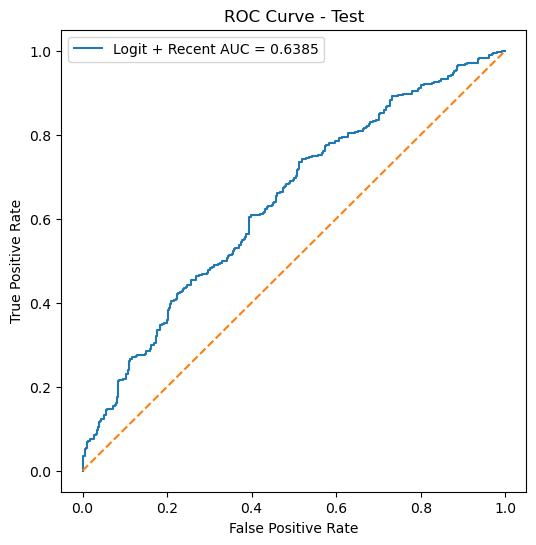

In [9]:
# -----------------------------
# ROC curve
# -----------------------------
test_auc_recent = roc_auc_score(y_test, y_test_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logit + Recent AUC = {test_auc_recent:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test")
plt.legend()
plt.show()

### Coefficient

In [10]:
# -----------------------------
# Encoding-normalized comment.
# Encoding-normalized comment.
# Encoding-normalized comment.
# -----------------------------
logit_coef = logit_recent_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_cols_recent,
    "coefficient": logit_coef,
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)

display(coef_df)

,feature,coefficient,abs_coefficient
0,sp_BB9_diff,0.279568,0.279568
1,lineup_OBP_diff,0.168349,0.168349
2,recent_10_win_rate_diff,0.145526,0.145526
3,lineup_OPS_diff,0.115011,0.115011
4,rest_days_diff,0.106820,0.106820
5,sp_HR9_diff,0.105530,0.105530
6,recent_5_runs_for_avg_diff,0.095538,0.095538
7,recent_5_run_diff_avg_diff,0.092065,0.092065
8,lineup_SLG_diff,0.064752,0.064752
9,sp_KBB_diff,0.052429,0.052429


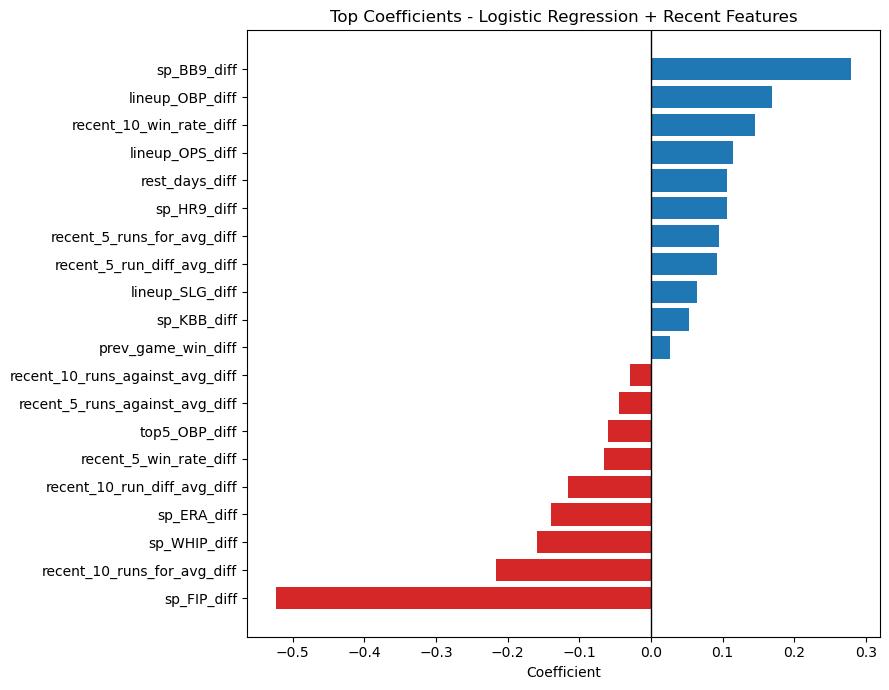

In [11]:
# Encoding-normalized comment.
top_coef_df = coef_df.sort_values("abs_coefficient", ascending=False).head(20).sort_values("coefficient")

plt.figure(figsize=(9, 7))
colors = np.where(top_coef_df["coefficient"] >= 0, "tab:blue", "tab:red")
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient")
plt.title("Top Coefficients - Logistic Regression + Recent Features")
plt.tight_layout()
plt.show()

### Prediction List

In [12]:
# -----------------------------
# test prediction dataframe
# -----------------------------
test_pred_df = test_df.copy()
test_pred_df["y_true"] = y_test.values
test_pred_df["y_pred"] = y_test_pred
test_pred_df["y_proba"] = y_test_proba
test_pred_df["correct"] = (test_pred_df["y_true"] == test_pred_df["y_pred"]).astype(int)

display_cols = [
    "game_id",
    "game_date",
    "season",
    "home_team_code",
    "away_team_code",
    "home_score",
    "away_score",
    "y_true",
    "y_pred",
    "y_proba",
    "correct",
]

display(test_pred_df[display_cols].head())

,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_true,y_pred,y_proba,correct
1405,20250001,2025-03-22 05:00:00,2025,5002,3001,12.0,2.0,1,1,0.655707,1
1406,20250002,2025-03-22 05:00:00,2025,9002,6002,6.0,5.0,1,1,0.670038,1
1407,20250003,2025-03-22 05:00:00,2025,1001,10001,13.0,5.0,1,1,0.627773,1
1408,20250004,2025-03-22 05:00:00,2025,12001,7002,3.0,4.0,0,0,0.264787,1
1409,20250005,2025-03-22 05:00:00,2025,2002,11001,9.0,2.0,1,1,0.632061,1


In [13]:
# -----------------------------
# Encoding-normalized comment.
# -----------------------------
top_test_pred_df = test_pred_df.sort_values("y_proba", ascending=False).copy()
low_test_pred_df = test_pred_df.sort_values("y_proba", ascending=True).copy()

print("=== Top 20 highest home-win probability games ===")
display(top_test_pred_df[display_cols].head(20))

print("=== Top 20 lowest home-win probability games ===")
display(low_test_pred_df[display_cols].head(20))

=== Top 20 highest home-win probability games ===


,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_true,y_pred,y_proba,correct
1514,20250127,2025-04-20 05:00:00,2025,9002,5002,9.0,3.0,1,1,0.999482,1
1986,20250642,2025-08-24 09:00:00,2025,1001,10001,7.0,4.0,1,1,0.886357,1
1419,20250015,2025-03-25 09:30:00,2025,2002,10001,11.0,6.0,1,1,0.883907,1
2010,20250666,2025-08-30 09:00:00,2025,5002,10001,6.0,5.0,1,1,0.882718,1
1890,20250537,2025-07-31 09:30:00,2025,9002,10001,4.0,2.0,1,1,0.860173,1
2108,20250954,2025-09-30 09:30:00,2025,7002,3001,1.0,0.0,1,1,0.854226,1
1517,20250130,2025-04-20 05:00:00,2025,7002,11001,7.0,1.0,1,1,0.846611,1
2058,20250905,2025-09-14 08:00:00,2025,11001,6002,6.0,0.0,1,1,0.843331,1
1539,20250153,2025-04-26 08:00:00,2025,1001,11001,9.0,1.0,1,1,0.834996,1
1935,20250587,2025-08-12 09:30:00,2025,9002,10001,3.0,1.0,1,1,0.831062,1


=== Top 20 lowest home-win probability games ===


,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_true,y_pred,y_proba,correct
1529,20250144,2025-04-24 09:30:00,2025,12001,9002,5.0,6.0,0,0,0.061438,1
1590,20250215,2025-05-10 05:00:00,2025,10001,7002,1.0,9.0,0,0,0.098571,1
1903,20250551,2025-08-03 05:00:00,2025,10001,3001,3.0,9.0,0,0,0.104423,1
1456,20250060,2025-04-04 09:30:00,2025,10001,11001,5.0,1.0,1,0,0.109689,0
1469,20250075,2025-04-08 09:30:00,2025,10001,5002,1.0,13.0,0,0,0.117877,1
1459,20250065,2025-04-05 08:00:00,2025,10001,11001,5.0,7.0,0,0,0.121887,1
1599,20250220,2025-05-11 05:00:00,2025,10001,7002,0.0,8.0,0,0,0.134818,1
1667,20250286,2025-05-28 09:30:00,2025,5002,7002,5.0,6.0,0,0,0.144422,1
1645,20250263,2025-05-22 09:30:00,2025,11001,7002,4.0,3.0,1,0,0.154814,0
1505,20250117,2025-04-18 09:30:00,2025,9002,5002,1.0,5.0,0,0,0.156429,1


### Lift

In [14]:
def calculate_lift_table(y_true, y_proba, n_bins=10):
    """
    Encoding-normalized docstring.
    """
    lift_df = pd.DataFrame({
        "y_true": y_true,
        "y_proba": y_proba,
    }).sort_values("y_proba", ascending=False).reset_index(drop=True)

    lift_df["bin"] = pd.qcut(
        lift_df.index + 1,
        q=n_bins,
        labels=False,
    ) + 1

    overall_rate = lift_df["y_true"].mean()

    summary = (
        lift_df.groupby("bin")
        .agg(
            n=("y_true", "size"),
            actual_win_rate=("y_true", "mean"),
            avg_proba=("y_proba", "mean"),
        )
        .reset_index()
    )

    summary["lift"] = summary["actual_win_rate"] / overall_rate
    return summary, lift_df

In [15]:
lift_table, lift_raw = calculate_lift_table(y_test, y_test_proba, n_bins=10)

print("=== Lift Table ===")
display(lift_table)

=== Lift Table ===


,bin,n,actual_win_rate,avg_proba,lift
0,1,71,0.718310,0.787746,1.446823
1,2,71,0.633803,0.681750,1.276609
2,3,71,0.605634,0.619776,1.219870
3,4,71,0.464789,0.572167,0.936180
4,5,71,0.577465,0.527023,1.163132
5,6,70,0.457143,0.480687,0.920779
6,7,71,0.478873,0.430766,0.964549
7,8,71,0.394366,0.387332,0.794334
8,9,71,0.309859,0.321393,0.624120
9,10,71,0.323944,0.225601,0.652489


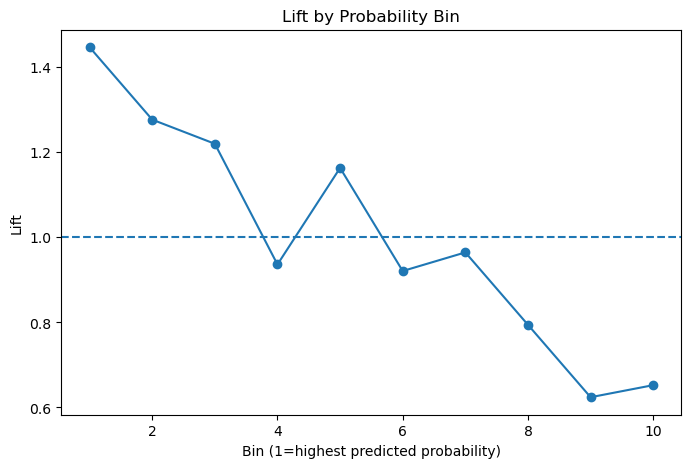

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(lift_table["bin"], lift_table["lift"], marker="o")
plt.axhline(y=1.0, linestyle="--")
plt.xlabel("Bin (1=highest predicted probability)")
plt.ylabel("Lift")
plt.title("Lift by Probability Bin")
plt.show()

### Threshold Evaluation

In [17]:
def evaluate_thresholds(y_true, y_proba, thresholds=np.arange(0.5, 0.95, 0.05)):
    rows = []

    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    for th in thresholds:
        mask = y_proba >= th
        n_selected = mask.sum()

        if n_selected == 0:
            rows.append({
                "threshold": th,
                "n_selected": 0,
                "accuracy": np.nan,
                "actual_win_rate": np.nan,
            })
            continue

        y_sel = y_true[mask]
        pred_sel = (y_proba[mask] >= th).astype(int)

        rows.append({
            "threshold": th,
            "n_selected": n_selected,
            "accuracy": (y_sel == pred_sel).mean(),
            "actual_win_rate": y_sel.mean(),
        })

    return pd.DataFrame(rows)

In [18]:
threshold_eval_df = evaluate_thresholds(y_test.values, y_test_proba)
display(threshold_eval_df)

,threshold,n_selected,accuracy,actual_win_rate
0,0.50,366,0.587432,0.587432
1,0.55,283,0.607774,0.607774
2,0.60,199,0.638191,0.638191
3,0.65,137,0.693431,0.693431
4,0.70,88,0.670455,0.670455
5,0.75,53,0.735849,0.735849
6,0.80,27,0.851852,0.851852
7,0.85,6,1.000000,1.000000
8,0.90,1,1.000000,1.000000


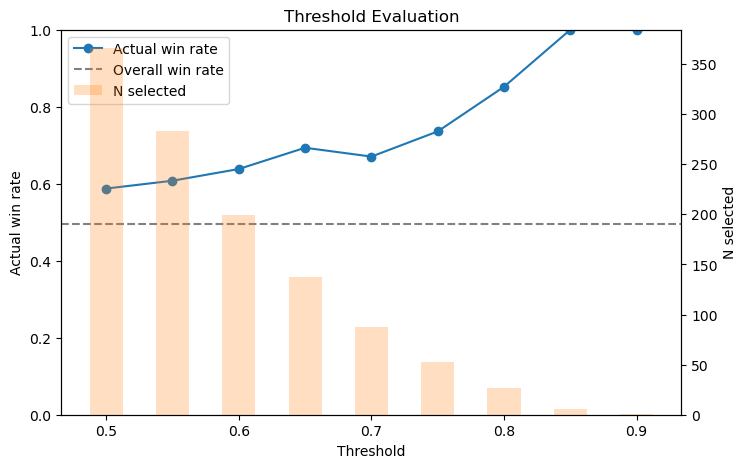

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(threshold_eval_df["threshold"], threshold_eval_df["actual_win_rate"], marker="o", label="Actual win rate")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Actual win rate")
ax1.set_ylim(0, 1)
ax1.axhline(y_test.mean(), linestyle="--", color="gray", label="Overall win rate")

ax2 = ax1.twinx()
ax2.bar(threshold_eval_df["threshold"], threshold_eval_df["n_selected"], width=0.025, alpha=0.25, color="tab:orange", label="N selected")
ax2.set_ylabel("N selected")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Threshold Evaluation")
plt.show()

### Feature Correlation

In [20]:
# -----------------------------
# Encoding-normalized comment.
# -----------------------------
corr_df = model_input[feature_cols_recent + ["y_home_win"]].copy()
corr_matrix = corr_df.corr(numeric_only=True)

display(corr_matrix.round(3))

,lineup_OPS_diff,lineup_OBP_diff,lineup_SLG_diff,top5_OPS_diff,top5_OBP_diff,sp_ERA_diff,sp_FIP_diff,sp_WHIP_diff,sp_K9_diff,sp_BB9_diff,...,recent_5_runs_for_avg_diff,recent_5_runs_against_avg_diff,recent_5_run_diff_avg_diff,recent_10_win_rate_diff,recent_10_runs_for_avg_diff,recent_10_runs_against_avg_diff,recent_10_run_diff_avg_diff,rest_days_diff,prev_game_win_diff,y_home_win
lineup_OPS_diff,1.000,0.790,0.947,0.891,0.689,-0.047,-0.013,0.008,-0.014,-0.023,...,0.242,-0.097,0.222,0.218,0.310,-0.101,0.265,0.046,0.091,0.101
lineup_OBP_diff,0.790,1.000,0.552,0.660,0.849,-0.089,-0.074,-0.007,-0.004,-0.061,...,0.253,-0.162,0.271,0.238,0.317,-0.175,0.317,0.059,0.095,0.117
lineup_SLG_diff,0.947,0.552,1.000,0.867,0.493,-0.018,0.021,0.015,-0.018,0.000,...,0.197,-0.047,0.160,0.172,0.256,-0.046,0.194,0.032,0.074,0.076
top5_OPS_diff,0.891,0.660,0.867,1.000,0.734,-0.049,-0.004,0.007,-0.006,-0.022,...,0.192,-0.048,0.157,0.158,0.250,-0.053,0.195,0.052,0.072,0.088
top5_OBP_diff,0.689,0.849,0.493,0.734,1.000,-0.091,-0.047,-0.012,-0.046,-0.063,...,0.199,-0.095,0.192,0.164,0.249,-0.106,0.229,0.067,0.065,0.087
sp_ERA_diff,-0.047,-0.089,-0.018,-0.049,-0.091,1.000,0.643,0.739,-0.266,0.689,...,0.005,0.012,-0.005,-0.016,-0.005,0.051,-0.037,-0.029,-0.006,-0.184
sp_FIP_diff,-0.013,-0.074,0.021,-0.004,-0.047,0.643,1.000,0.169,-0.437,0.727,...,-0.002,0.044,-0.030,-0.031,-0.025,0.067,-0.060,-0.038,0.007,-0.213
sp_WHIP_diff,0.008,-0.007,0.015,0.007,-0.012,0.739,0.169,1.000,-0.241,0.820,...,0.008,-0.047,0.036,0.019,0.011,-0.010,0.013,-0.007,0.003,-0.066
sp_K9_diff,-0.014,-0.004,-0.018,-0.006,-0.046,-0.266,-0.437,-0.241,1.000,0.065,...,0.022,-0.065,0.057,0.052,0.007,-0.079,0.057,0.030,0.017,0.147
sp_BB9_diff,-0.023,-0.061,0.000,-0.022,-0.063,0.689,0.727,0.820,0.065,1.000,...,0.027,-0.011,0.024,0.005,-0.003,0.015,-0.012,-0.012,0.022,-0.129


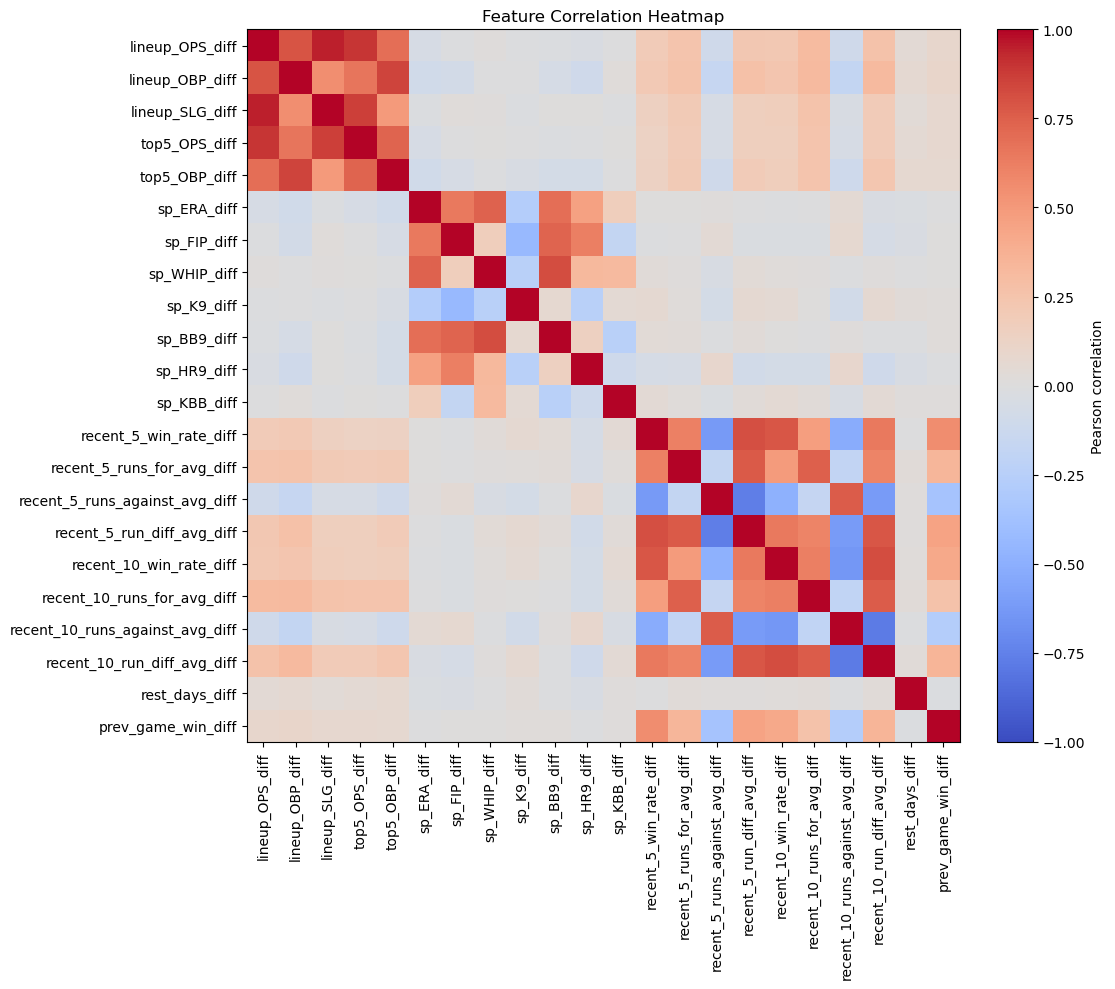

In [21]:
# Encoding-normalized comment.
feature_corr = corr_matrix.loc[feature_cols_recent, feature_cols_recent]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(feature_corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(feature_cols_recent)))
ax.set_yticks(np.arange(len(feature_cols_recent)))
ax.set_xticklabels(feature_cols_recent, rotation=90)
ax.set_yticklabels(feature_cols_recent)
ax.set_title("Feature Correlation Heatmap")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")

plt.tight_layout()
plt.show()

In [22]:
# Encoding-normalized comment.
upper_mask = np.triu(np.ones(feature_corr.shape), k=1).astype(bool)

high_corr_pairs = (
    feature_corr.where(upper_mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
)
high_corr_pairs["abs_corr"] = high_corr_pairs["corr"].abs()
high_corr_pairs = high_corr_pairs.sort_values("abs_corr", ascending=False).reset_index(drop=True)

print("=== Top correlated feature pairs ===")
display(high_corr_pairs.head(30))

print("=== abs(corr) >= 0.80 ===")
display(high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.80])

=== Top correlated feature pairs ===


,feature_1,feature_2,corr,abs_corr
0,lineup_OPS_diff,lineup_SLG_diff,0.947269,0.947269
1,lineup_OPS_diff,top5_OPS_diff,0.890860,0.890860
2,lineup_SLG_diff,top5_OPS_diff,0.866982,0.866982
3,lineup_OBP_diff,top5_OBP_diff,0.849258,0.849258
4,sp_WHIP_diff,sp_BB9_diff,0.819791,0.819791
5,recent_10_win_rate_diff,recent_10_run_diff_avg_diff,0.819232,0.819232
6,recent_5_win_rate_diff,recent_5_run_diff_avg_diff,0.805590,0.805590
7,lineup_OPS_diff,lineup_OBP_diff,0.790005,0.790005
8,recent_5_run_diff_avg_diff,recent_10_run_diff_avg_diff,0.788643,0.788643
9,recent_5_win_rate_diff,recent_10_win_rate_diff,0.784771,0.784771


=== abs(corr) >= 0.80 ===


,feature_1,feature_2,corr,abs_corr
0,lineup_OPS_diff,lineup_SLG_diff,0.947269,0.947269
1,lineup_OPS_diff,top5_OPS_diff,0.890860,0.890860
2,lineup_SLG_diff,top5_OPS_diff,0.866982,0.866982
3,lineup_OBP_diff,top5_OBP_diff,0.849258,0.849258
4,sp_WHIP_diff,sp_BB9_diff,0.819791,0.819791
5,recent_10_win_rate_diff,recent_10_run_diff_avg_diff,0.819232,0.819232
6,recent_5_win_rate_diff,recent_5_run_diff_avg_diff,0.805590,0.805590


,feature,corr_with_target
0,sp_FIP_diff,-0.213364
1,sp_ERA_diff,-0.183984
2,sp_K9_diff,0.146682
3,sp_HR9_diff,-0.141736
4,sp_BB9_diff,-0.128970
5,lineup_OBP_diff,0.117300
6,lineup_OPS_diff,0.101003
7,top5_OPS_diff,0.088293
8,top5_OBP_diff,0.086609
9,recent_5_runs_against_avg_diff,-0.077274


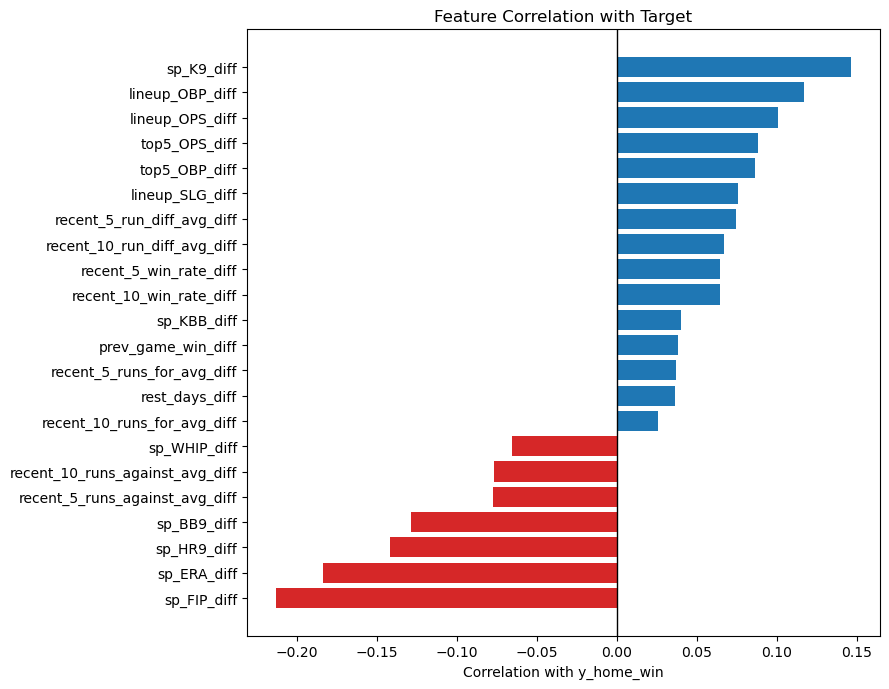

In [23]:
# Encoding-normalized comment.
target_corr = (
    corr_matrix["y_home_win"]
    .drop("y_home_win")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "y_home_win": "corr_with_target"})
)

display(target_corr)

plot_target_corr = target_corr.sort_values("corr_with_target")

plt.figure(figsize=(9, 7))
colors = np.where(plot_target_corr["corr_with_target"] >= 0, "tab:blue", "tab:red")
plt.barh(plot_target_corr["feature"], plot_target_corr["corr_with_target"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with y_home_win")
plt.title("Feature Correlation with Target")
plt.tight_layout()
plt.show()

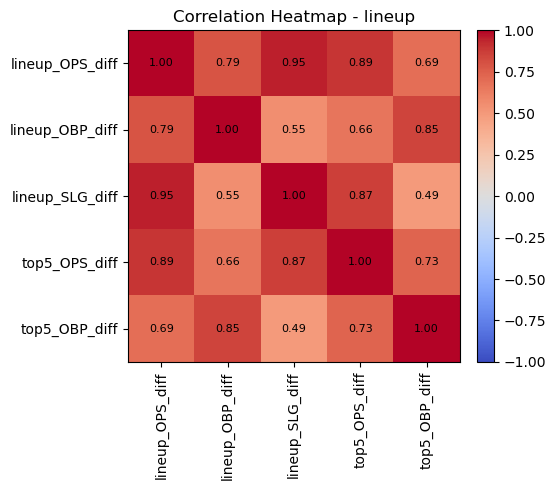

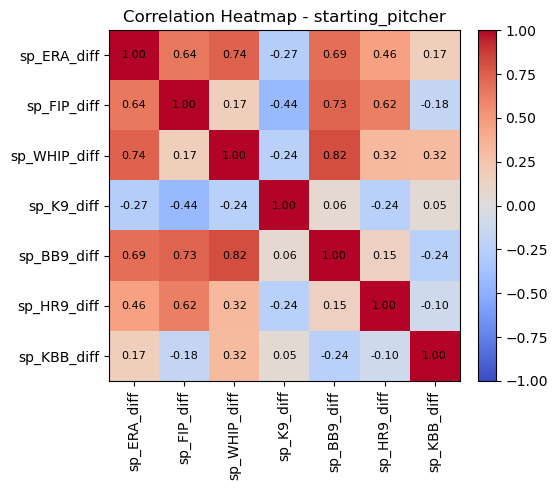

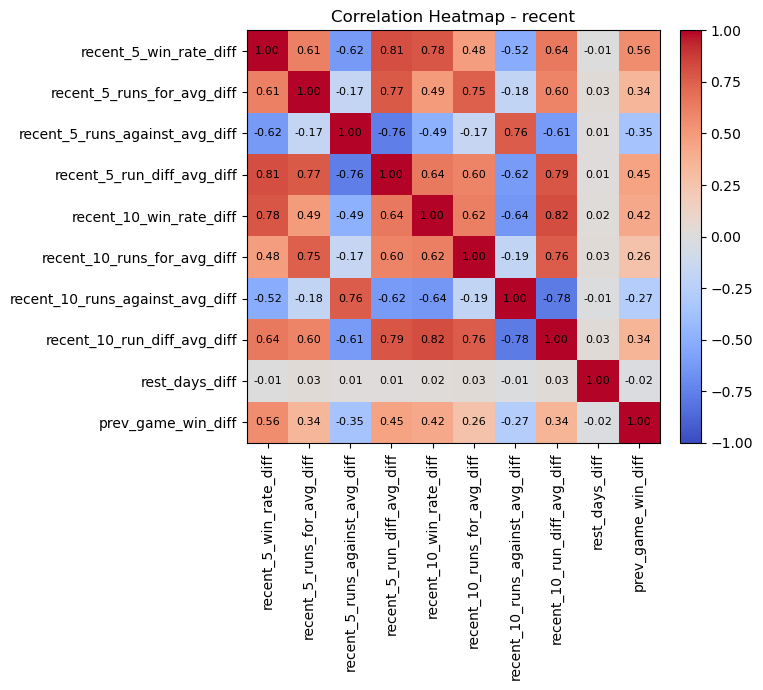

In [24]:
# Encoding-normalized comment.
feature_groups = {
    "lineup": [c for c in feature_cols_recent if "lineup" in c or "top5" in c],
    "starting_pitcher": [c for c in feature_cols_recent if c.startswith("sp_")],
    "recent": [c for c in feature_cols_recent if c.startswith("recent_") or c in ["rest_days_diff", "prev_game_win_diff"]],
}

for group_name, cols in feature_groups.items():
    if len(cols) < 2:
        continue

    group_corr = feature_corr.loc[cols, cols]

    fig, ax = plt.subplots(figsize=(max(6, len(cols) * 0.8), max(5, len(cols) * 0.7)))
    im = ax.imshow(group_corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(cols)))
    ax.set_yticks(np.arange(len(cols)))
    ax.set_xticklabels(cols, rotation=90)
    ax.set_yticklabels(cols)
    ax.set_title(f"Correlation Heatmap - {group_name}")

    for i in range(len(cols)):
        for j in range(len(cols)):
            val = group_corr.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

### Reduced Core Feature Modeling

Use `reduced_core_features` only and evaluate two time splits.

- Step 1: train on 2023, test on 2024
- Step 2: train on 2023~2024, test on 2025
- Save the final 2023~2024 trained model and feature list.

In [34]:
# Reduced Core Feature Modeling
# 1) 2023 train -> 2024 test
# 2) 2023~2024 train -> 2025 test

from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)


# Reduced core feature set based on the correlation heatmap.
# - lineup: keep OPS/OBP; remove highly overlapping SLG/top5 features.
# - starting pitcher: keep FIP/ERA/K9/BB9/HR9/KBB; remove WHIP due to overlap with BB9.
# - recent flow: keep representative signals for win rate, run diff, runs allowed, rest, and previous result.
reduced_core_features = [
    "lineup_OPS_diff",
    "lineup_OBP_diff",
    "sp_FIP_diff",
    "sp_ERA_diff",
    "sp_K9_diff",
    "sp_BB9_diff",
    "sp_HR9_diff",
    "sp_KBB_diff",
    "recent_10_win_rate_diff",
    "recent_5_run_diff_avg_diff",
    "recent_5_runs_against_avg_diff",
    "rest_days_diff",
    "prev_game_win_diff",
]
reduced_core_features = [c for c in reduced_core_features if c in feature_cols_recent]
removed_from_all_recent = [c for c in feature_cols_recent if c not in reduced_core_features]

print("=== reduced_core_features ===")
print("feature count:", len(reduced_core_features))
print(reduced_core_features)

print("\n=== removed from all recent features ===")
print("removed count:", len(removed_from_all_recent))
print(removed_from_all_recent)


def make_reduced_core_model(C=1.0):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=C,
                    solver="lbfgs",
                    max_iter=5000,
                    random_state=427,
                ),
            ),
        ]
    )


def evaluate_reduced_core_model(model_name, model, feature_cols, fit_df, eval_df):
    X_fit = fit_df[feature_cols].copy()
    y_fit = fit_df["y_home_win"].astype(int).copy()
    X_eval = eval_df[feature_cols].copy()
    y_eval = eval_df["y_home_win"].astype(int).copy()

    model.fit(X_fit, y_fit)

    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]

    lift_table_eval, _ = calculate_lift_table(y_eval, proba, n_bins=10)

    high_065 = proba >= 0.65
    high_075 = proba >= 0.75
    high_080 = proba >= 0.80

    result = {
        "model": model_name,
        "train_seasons": ",".join(map(str, sorted(fit_df["season"].unique()))),
        "test_season": ",".join(map(str, sorted(eval_df["season"].unique()))),
        "n_train": len(fit_df),
        "n_test": len(eval_df),
        "n_features": len(feature_cols),
        "accuracy": accuracy_score(y_eval, pred),
        "auc": roc_auc_score(y_eval, proba),
        "brier": brier_score_loss(y_eval, proba),
        "top_decile_win_rate": lift_table_eval.loc[0, "actual_win_rate"],
        "top_decile_lift": lift_table_eval.loc[0, "lift"],
        "n_proba_ge_065": int(high_065.sum()),
        "win_rate_ge_065": y_eval[high_065].mean() if high_065.sum() > 0 else np.nan,
        "n_proba_ge_075": int(high_075.sum()),
        "win_rate_ge_075": y_eval[high_075].mean() if high_075.sum() > 0 else np.nan,
        "n_proba_ge_080": int(high_080.sum()),
        "win_rate_ge_080": y_eval[high_080].mean() if high_080.sum() > 0 else np.nan,
    }

    pred_df = eval_df.copy()
    pred_df["y_true"] = y_eval.values
    pred_df["y_pred"] = pred
    pred_df["y_proba"] = proba
    pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"]).astype(int)

    return result, model, pred_df, lift_table_eval


# Step 1: train on 2023 -> test on 2024
train_2023_df = model_input[model_input["season"] == 2023].copy()
test_2024_df = model_input[model_input["season"] == 2024].copy()

train_2023_df = train_2023_df.dropna(subset=reduced_core_features + ["y_home_win"]).copy()
test_2024_df = test_2024_df.dropna(subset=reduced_core_features + ["y_home_win"]).copy()

reduced_core_model_23_to_24 = make_reduced_core_model(C=1.0)
result_23_to_24, reduced_core_model_23_to_24, pred_2024_reduced_core, lift_2024_reduced_core = evaluate_reduced_core_model(
    model_name="reduced_core_l2_C1_2023_train_2024_test",
    model=reduced_core_model_23_to_24,
    feature_cols=reduced_core_features,
    fit_df=train_2023_df,
    eval_df=test_2024_df,
)

print("\n=== 2023 train -> 2024 test ===")
display(pd.DataFrame([result_23_to_24]).round(4))
print("\n=== 2024 lift table ===")
display(lift_2024_reduced_core.round(4))


# Step 2: train on 2023~2024 -> test on 2025
train_2023_2024_df = model_input[model_input["season"] <= 2024].copy()
test_2025_df = model_input[model_input["season"] == 2025].copy()

train_2023_2024_df = train_2023_2024_df.dropna(subset=reduced_core_features + ["y_home_win"]).copy()
test_2025_df = test_2025_df.dropna(subset=reduced_core_features + ["y_home_win"]).copy()

reduced_core_model_2324_to_25 = make_reduced_core_model(C=1.0)
result_2324_to_25, reduced_core_model_2324_to_25, pred_2025_reduced_core, lift_2025_reduced_core = evaluate_reduced_core_model(
    model_name="reduced_core_l2_C1_2023_2024_train_2025_test",
    model=reduced_core_model_2324_to_25,
    feature_cols=reduced_core_features,
    fit_df=train_2023_2024_df,
    eval_df=test_2025_df,
)

reduced_core_result = pd.DataFrame([result_23_to_24, result_2324_to_25])

print("\n=== reduced core model result ===")
display(reduced_core_result.round(4))

print("\n=== 2025 lift table: 2023~2024 train -> 2025 test ===")
display(lift_2025_reduced_core.round(4))


# Save final candidate trained on 2023~2024.
joblib.dump(reduced_core_model_2324_to_25, "logit_model_reduced_core.pkl")
joblib.dump(reduced_core_features, "feature_cols_reduced_core.pkl")

print("\nsaved: logit_model_reduced_core.pkl, feature_cols_reduced_core.pkl")


# Coefficients from the standardized logistic regression model.
reduced_core_coef_df = pd.DataFrame(
    {
        "feature": reduced_core_features,
        "coefficient": reduced_core_model_2324_to_25.named_steps["model"].coef_[0],
    }
)
reduced_core_coef_df["abs_coefficient"] = reduced_core_coef_df["coefficient"].abs()
reduced_core_coef_df = reduced_core_coef_df.sort_values(
    "abs_coefficient",
    ascending=False,
).reset_index(drop=True)

print("\n=== reduced core coefficients: final 2023~2024 train model ===")
display(reduced_core_coef_df.round(4))

print(
    """
Decision memo

1. 2023 -> 2024 is a validation-style split for checking whether reduced core features hold up in the next season.
2. 2023~2024 -> 2025 is the final test split for the current model decision.
3. For overall prediction quality, check AUC and Brier first.
4. For high-confidence game selection, also check top decile win rate and threshold win rates.
5. The reduced core set keeps representative signals from highly correlated feature groups, aiming for more stable coefficients and better generalization than the full 22-feature recent model.
"""
)

=== reduced_core_features ===
feature count: 13
['lineup_OPS_diff', 'lineup_OBP_diff', 'sp_FIP_diff', 'sp_ERA_diff', 'sp_K9_diff', 'sp_BB9_diff', 'sp_HR9_diff', 'sp_KBB_diff', 'recent_10_win_rate_diff', 'recent_5_run_diff_avg_diff', 'recent_5_runs_against_avg_diff', 'rest_days_diff', 'prev_game_win_diff']

=== removed from all recent features ===
removed count: 9
['lineup_SLG_diff', 'top5_OPS_diff', 'top5_OBP_diff', 'sp_WHIP_diff', 'recent_5_win_rate_diff', 'recent_5_runs_for_avg_diff', 'recent_10_runs_for_avg_diff', 'recent_10_runs_against_avg_diff', 'recent_10_run_diff_avg_diff']

=== 2023 train -> 2024 test ===


,model,train_seasons,test_season,n_train,n_test,n_features,accuracy,auc,brier,top_decile_win_rate,top_decile_lift,n_proba_ge_065,win_rate_ge_065,n_proba_ge_075,win_rate_ge_075,n_proba_ge_080,win_rate_ge_080
0,reduced_core_l2_C1_2023_train_2024_test,2023,2024,658,711,13,0.5963,0.6255,0.2401,0.7361,1.4579,153,0.6732,60,0.7667,33,0.7879



=== 2024 lift table ===


,bin,n,actual_win_rate,avg_proba,lift
0,1,72,0.7361,0.8162,1.4579
1,2,71,0.5915,0.6908,1.1716
2,3,71,0.5775,0.6286,1.1437
3,4,71,0.4930,0.5801,0.9763
4,5,71,0.4930,0.5339,0.9763
5,6,71,0.6056,0.4952,1.1995
6,7,70,0.4286,0.4449,0.8488
7,8,72,0.4028,0.3961,0.7977
8,9,71,0.4366,0.3330,0.8647
9,10,71,0.2817,0.2138,0.5579



=== reduced core model result ===


...


=== 2025 lift table: 2023~2024 train -> 2025 test ===


,bin,n,actual_win_rate,avg_proba,lift
0,1,71,0.7183,0.7784,1.4468
1,2,71,0.6620,0.6711,1.3333
2,3,71,0.5775,0.6127,1.1631
3,4,71,0.5493,0.5694,1.1064
4,5,71,0.4930,0.5288,0.9929
5,6,70,0.5000,0.4817,1.0071
6,7,71,0.3944,0.4330,0.7943
7,8,71,0.4225,0.3920,0.8511
8,9,71,0.3662,0.3320,0.7376
9,10,71,0.2817,0.2374,0.5674



saved: logit_model_reduced_core.pkl, feature_cols_reduced_core.pkl

=== reduced core coefficients: final 2023~2024 train model ===


,feature,coefficient,abs_coefficient
0,sp_FIP_diff,-0.5454,0.5454
1,sp_ERA_diff,-0.2638,0.2638
2,sp_BB9_diff,0.2483,0.2483
3,lineup_OPS_diff,0.2072,0.2072
4,sp_HR9_diff,0.1317,0.1317
5,rest_days_diff,0.1072,0.1072
6,recent_5_runs_against_avg_diff,-0.1023,0.1023
7,sp_KBB_diff,0.0570,0.0570
8,lineup_OBP_diff,0.0514,0.0514
9,prev_game_win_diff,0.0368,0.0368



Decision memo

1. 2023 -> 2024 is a validation-style split for checking whether reduced core features hold up in the next season.
2. 2023~2024 -> 2025 is the final test split for the current model decision.
3. For overall prediction quality, check AUC and Brier first.
4. For high-confidence game selection, also check top decile win rate and threshold win rates.
5. The reduced core set keeps representative signals from highly correlated feature groups, aiming for more stable coefficients and better generalization than the full 22-feature recent model.



### Reduced Core Model Evaluation

In [35]:
# -----------------------------
# reduced core model summary
# -----------------------------
reduced_core_y_true = pred_2025_reduced_core["y_true"].astype(int).values
reduced_core_y_pred = pred_2025_reduced_core["y_pred"].astype(int).values
reduced_core_y_proba = pred_2025_reduced_core["y_proba"].astype(float).values

recent_2025_summary = {
    "model": "all_recent_l2_2023_2024_train_2025_test",
    "n_features": len(feature_cols_recent),
    "n_test": len(y_test),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "auc": roc_auc_score(y_test, y_test_proba),
    "brier": brier_score_loss(y_test, y_test_proba),
}

reduced_core_2025_summary = {
    "model": "reduced_core_l2_2023_2024_train_2025_test",
    "n_features": len(reduced_core_features),
    "n_test": len(reduced_core_y_true),
    "accuracy": accuracy_score(reduced_core_y_true, reduced_core_y_pred),
    "auc": roc_auc_score(reduced_core_y_true, reduced_core_y_proba),
    "brier": brier_score_loss(reduced_core_y_true, reduced_core_y_proba),
}

model_eval_compare = pd.DataFrame([recent_2025_summary, reduced_core_2025_summary])
display(model_eval_compare.round(4))

print("=== reduced core validation / test summary ===")
display(reduced_core_result.round(4))

,model,n_features,n_test,accuracy,auc,brier
0,all_recent_l2_2023_2024_train_2025_test,22,709,0.5938,0.6385,0.2365
1,reduced_core_l2_2023_2024_train_2025_test,13,709,0.6051,0.6472,0.2338


=== reduced core validation / test summary ===


,model,train_seasons,test_season,n_train,n_test,n_features,accuracy,auc,brier,top_decile_win_rate,top_decile_lift,n_proba_ge_065,win_rate_ge_065,n_proba_ge_075,win_rate_ge_075,n_proba_ge_080,win_rate_ge_080
0,reduced_core_l2_C1_2023_train_2024_test,2023,2024,658,711,13,0.5963,0.6255,0.2401,0.7361,1.4579,153,0.6732,60,0.7667,33,0.7879
1,reduced_core_l2_C1_2023_2024_train_2025_test,"2023,2024",2025,1369,709,13,0.6051,0.6472,0.2338,0.7183,1.4468,127,0.7087,45,0.7111,22,0.8636


### Reduced Core ROC Curve

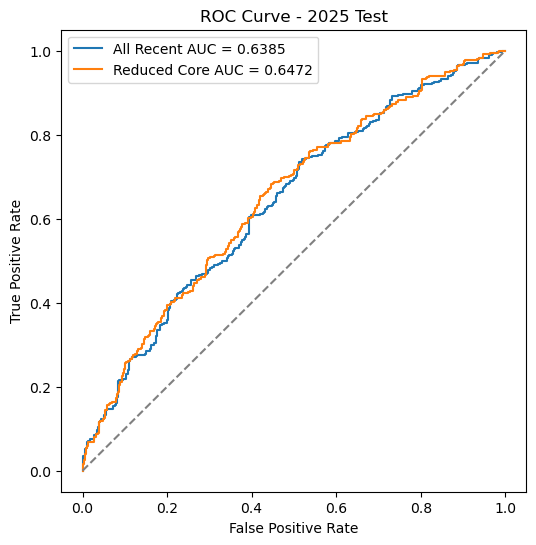

In [36]:
# -----------------------------
# ROC curve: all recent vs reduced core
# -----------------------------
recent_fpr, recent_tpr, _ = roc_curve(y_test, y_test_proba)
reduced_fpr, reduced_tpr, _ = roc_curve(reduced_core_y_true, reduced_core_y_proba)

recent_auc = roc_auc_score(y_test, y_test_proba)
reduced_auc = roc_auc_score(reduced_core_y_true, reduced_core_y_proba)

plt.figure(figsize=(6, 6))
plt.plot(recent_fpr, recent_tpr, label=f"All Recent AUC = {recent_auc:.4f}")
plt.plot(reduced_fpr, reduced_tpr, label=f"Reduced Core AUC = {reduced_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 2025 Test")
plt.legend()
plt.show()

### Reduced Core Coefficient

,feature,coefficient,abs_coefficient
0,sp_FIP_diff,-0.5454,0.5454
1,sp_ERA_diff,-0.2638,0.2638
2,sp_BB9_diff,0.2483,0.2483
3,lineup_OPS_diff,0.2072,0.2072
4,sp_HR9_diff,0.1317,0.1317
5,rest_days_diff,0.1072,0.1072
6,recent_5_runs_against_avg_diff,-0.1023,0.1023
7,sp_KBB_diff,0.0570,0.0570
8,lineup_OBP_diff,0.0514,0.0514
9,prev_game_win_diff,0.0368,0.0368


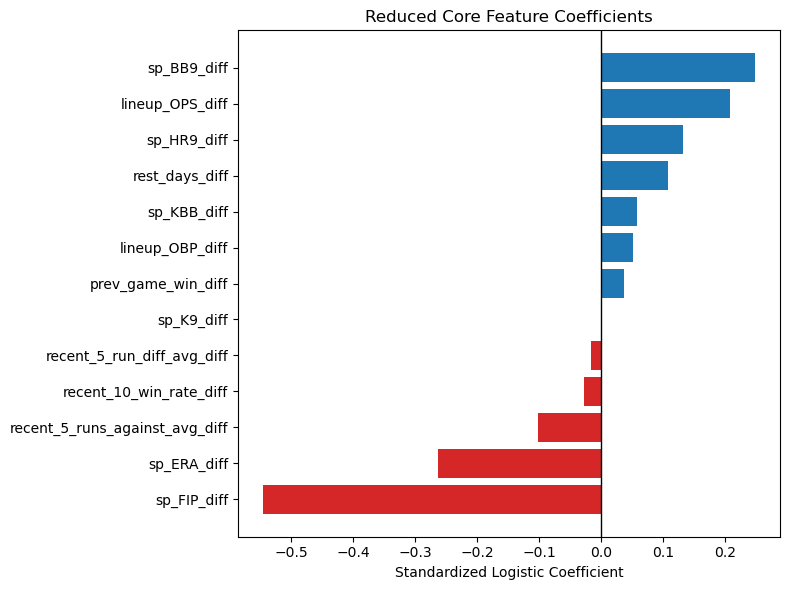

In [37]:
# -----------------------------
# coefficient table and chart
# -----------------------------
display(reduced_core_coef_df.round(4))

plot_coef_df = reduced_core_coef_df.sort_values("coefficient")

plt.figure(figsize=(8, 6))
colors = np.where(plot_coef_df["coefficient"] >= 0, "tab:blue", "tab:red")
plt.barh(plot_coef_df["feature"], plot_coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Standardized Logistic Coefficient")
plt.title("Reduced Core Feature Coefficients")
plt.tight_layout()
plt.show()

### Reduced Core Prediction List

In [38]:
# -----------------------------
# prediction list
# -----------------------------
reduced_core_display_cols = [
    "game_id",
    "game_date",
    "season",
    "home_team_code",
    "away_team_code",
    "home_score",
    "away_score",
    "y_true",
    "y_pred",
    "y_proba",
    "correct",
]

print("=== highest home-win probability ===")
display(
    pred_2025_reduced_core[reduced_core_display_cols]
    .sort_values("y_proba", ascending=False)
    .head(20)
    .round({"y_proba": 4})
)

print("=== lowest home-win probability ===")
display(
    pred_2025_reduced_core[reduced_core_display_cols]
    .sort_values("y_proba", ascending=True)
    .head(20)
    .round({"y_proba": 4})
)

=== highest home-win probability ===


,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_true,y_pred,y_proba,correct
1514,20250127,2025-04-20 05:00:00,2025,9002,5002,9.0,3.0,1,1,0.9998,1
1986,20250642,2025-08-24 09:00:00,2025,1001,10001,7.0,4.0,1,1,0.8816,1
2010,20250666,2025-08-30 09:00:00,2025,5002,10001,6.0,5.0,1,1,0.8705,1
1419,20250015,2025-03-25 09:30:00,2025,2002,10001,11.0,6.0,1,1,0.8657,1
2059,20250972,2025-09-15 09:30:00,2025,7002,10001,7.0,6.0,1,1,0.8650,1
1517,20250130,2025-04-20 05:00:00,2025,7002,11001,7.0,1.0,1,1,0.8638,1
2111,20250981,2025-10-01 09:30:00,2025,5002,11001,3.0,7.0,0,1,0.8471,0
2058,20250905,2025-09-14 08:00:00,2025,11001,6002,6.0,0.0,1,1,0.8316,1
1890,20250537,2025-07-31 09:30:00,2025,9002,10001,4.0,2.0,1,1,0.8302,1
1935,20250587,2025-08-12 09:30:00,2025,9002,10001,3.0,1.0,1,1,0.8266,1


=== lowest home-win probability ===


,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_true,y_pred,y_proba,correct
1529,20250144,2025-04-24 09:30:00,2025,12001,9002,5.0,6.0,0,0,0.0445,1
1570,20250188,2025-05-04 05:00:00,2025,1001,6002,6.0,11.0,0,0,0.1051,1
1505,20250117,2025-04-18 09:30:00,2025,9002,5002,1.0,5.0,0,0,0.1280,1
1590,20250215,2025-05-10 05:00:00,2025,10001,7002,1.0,9.0,0,0,0.1389,1
1469,20250075,2025-04-08 09:30:00,2025,10001,5002,1.0,13.0,0,0,0.1521,1
1456,20250060,2025-04-04 09:30:00,2025,10001,11001,5.0,1.0,1,0,0.1532,0
1903,20250551,2025-08-03 05:00:00,2025,10001,3001,3.0,9.0,0,0,0.1566,1
1645,20250263,2025-05-22 09:30:00,2025,11001,7002,4.0,3.0,1,0,0.1654,0
1667,20250286,2025-05-28 09:30:00,2025,5002,7002,5.0,6.0,0,0,0.1786,1
1599,20250220,2025-05-11 05:00:00,2025,10001,7002,0.0,8.0,0,0,0.1806,1


### Reduced Core Lift

,bin,n,actual_win_rate,avg_proba,lift
0,1,71,0.7183,0.7784,1.4468
1,2,71,0.6620,0.6711,1.3333
2,3,71,0.5775,0.6127,1.1631
3,4,71,0.5493,0.5694,1.1064
4,5,71,0.4930,0.5288,0.9929
5,6,70,0.5000,0.4817,1.0071
6,7,71,0.3944,0.4330,0.7943
7,8,71,0.4225,0.3920,0.8511
8,9,71,0.3662,0.3320,0.7376
9,10,71,0.2817,0.2374,0.5674


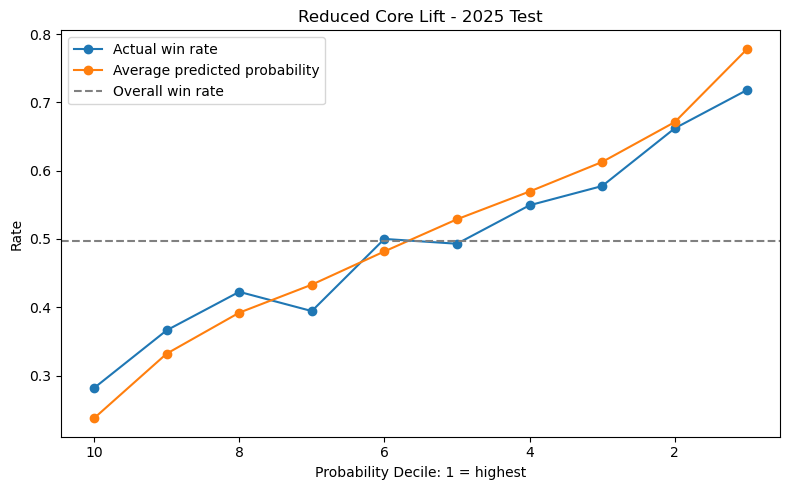

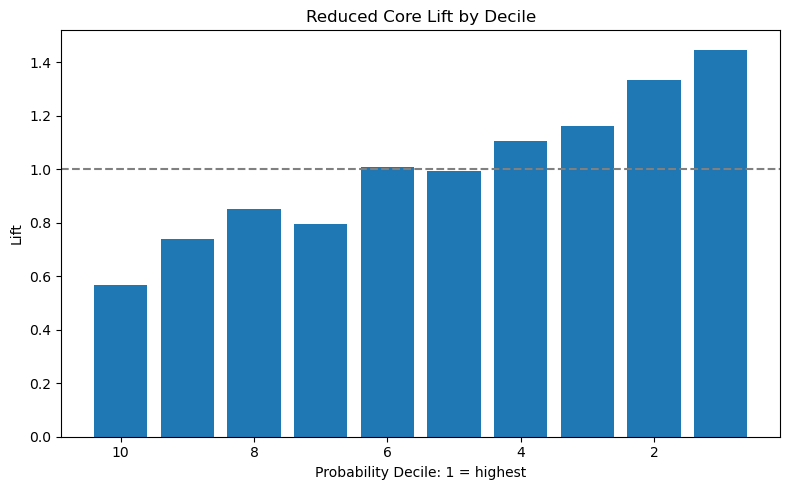

In [39]:
# -----------------------------
# lift table and chart
# -----------------------------
display(lift_2025_reduced_core.round(4))

plt.figure(figsize=(8, 5))
plt.plot(lift_2025_reduced_core["bin"], lift_2025_reduced_core["actual_win_rate"], marker="o", label="Actual win rate")
plt.plot(lift_2025_reduced_core["bin"], lift_2025_reduced_core["avg_proba"], marker="o", label="Average predicted probability")
plt.axhline(reduced_core_y_true.mean(), linestyle="--", color="gray", label="Overall win rate")
plt.gca().invert_xaxis()
plt.xlabel("Probability Decile: 1 = highest")
plt.ylabel("Rate")
plt.title("Reduced Core Lift - 2025 Test")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(lift_2025_reduced_core["bin"], lift_2025_reduced_core["lift"])
plt.axhline(1.0, linestyle="--", color="gray")
plt.gca().invert_xaxis()
plt.xlabel("Probability Decile: 1 = highest")
plt.ylabel("Lift")
plt.title("Reduced Core Lift by Decile")
plt.tight_layout()
plt.show()

### Reduced Core Threshold Evaluation

,threshold,n_selected,accuracy,actual_win_rate
0,0.50,364,0.5989,0.5989
1,0.55,286,0.6224,0.6224
2,0.60,198,0.6566,0.6566
3,0.65,127,0.7087,0.7087
4,0.70,81,0.7037,0.7037
5,0.75,45,0.7111,0.7111
6,0.80,22,0.8636,0.8636
7,0.85,6,1.0000,1.0000
8,0.90,1,1.0000,1.0000


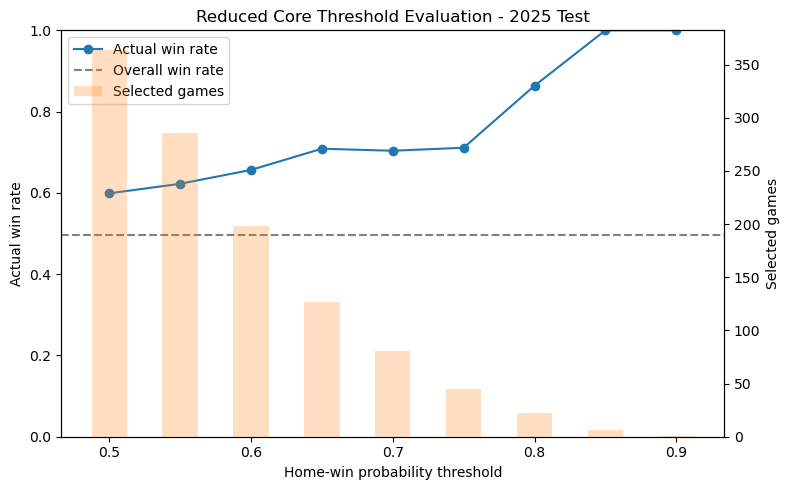

In [40]:
# -----------------------------
# threshold evaluation
# -----------------------------
reduced_core_threshold_eval = evaluate_thresholds(reduced_core_y_true, reduced_core_y_proba)
display(reduced_core_threshold_eval.round(4))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(reduced_core_threshold_eval["threshold"], reduced_core_threshold_eval["actual_win_rate"], marker="o", label="Actual win rate")
ax1.axhline(reduced_core_y_true.mean(), linestyle="--", color="gray", label="Overall win rate")
ax1.set_xlabel("Home-win probability threshold")
ax1.set_ylabel("Actual win rate")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.bar(
    reduced_core_threshold_eval["threshold"],
    reduced_core_threshold_eval["n_selected"],
    width=0.025,
    alpha=0.25,
    color="tab:orange",
    label="Selected games",
)
ax2.set_ylabel("Selected games")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("Reduced Core Threshold Evaluation - 2025 Test")
plt.tight_layout()
plt.show()

### Reduced Core Calibration and Error Check

,proba_bin,n,avg_proba,actual_win_rate,accuracy
0,"(-0.001, 0.1]",1,0.0445,0.0000,1.0000
1,"(0.1, 0.2]",13,0.1639,0.1538,0.8462
2,"(0.2, 0.3]",62,0.2608,0.3065,0.6935
3,"(0.3, 0.4]",116,0.3568,0.3966,0.6034
4,"(0.4, 0.5]",153,0.4476,0.4379,0.5621
5,"(0.5, 0.6]",166,0.5505,0.5301,0.5301
6,"(0.6, 0.7]",117,0.6429,0.6239,0.6239
7,"(0.7, 0.8]",59,0.7438,0.6441,0.6441
8,"(0.8, 0.9]",21,0.8300,0.8571,0.8571
9,"(0.9, 1.0]",1,0.9998,1.0000,1.0000


,pred_away_win,pred_home_win
actual_away_win,211,146
actual_home_win,134,218


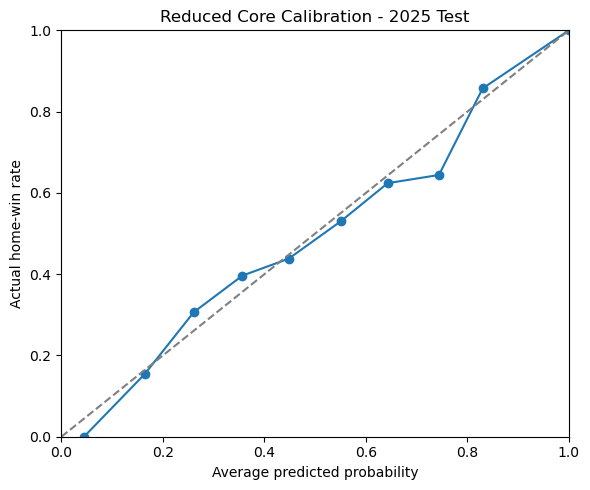

=== high-confidence misses ===


,game_id,game_date,season,home_team_code,away_team_code,home_score,away_score,y_true,y_pred,y_proba,...,sp_K9_diff,sp_BB9_diff,sp_HR9_diff,sp_KBB_diff,recent_10_win_rate_diff,recent_5_run_diff_avg_diff,recent_5_runs_against_avg_diff,rest_days_diff,prev_game_win_diff,confidence
2111,20250981,2025-10-01 09:30:00,2025,5002,11001,3.0,7.0,0,1,0.8471,...,-1.216,-5.533,-3.019,2.6945,-0.2000,-3.8,1.20,0.0,-1.0,0.8471
1456,20250060,2025-04-04 09:30:00,2025,10001,11001,5.0,1.0,1,0,0.1532,...,0.114,-1.079,-0.173,1.0444,-0.0286,2.0,-4.80,-5.0,0.0,0.8468
1645,20250263,2025-05-22 09:30:00,2025,11001,7002,4.0,3.0,1,0,0.1654,...,-7.797,4.001,0.788,-5.3591,0.2000,2.2,-1.40,0.0,1.0,0.8346
2026,20250865,2025-09-03 09:30:00,2025,1001,10001,3.0,4.0,0,1,0.8237,...,1.786,1.844,-0.074,-0.9980,0.6000,6.0,-2.80,2.0,1.0,0.8237
1732,20250352,2025-06-12 09:30:00,2025,12001,3001,7.0,12.0,0,1,0.8129,...,-0.486,-3.562,-2.966,2.7414,0.1000,3.8,-2.20,0.0,-1.0,0.8129
1483,20250089,2025-04-11 09:30:00,2025,2002,9002,3.0,9.0,0,1,0.7998,...,1.675,-5.173,-1.189,1.3567,-0.2000,-2.2,2.60,0.0,0.0,0.7998
1675,20250295,2025-05-29 09:30:00,2025,2002,10001,3.0,3.0,0,1,0.7930,...,3.007,-2.255,-1.307,2.5255,0.5000,4.4,-2.00,0.0,1.0,0.7930
1956,20250612,2025-08-17 09:00:00,2025,6002,2002,4.0,2.0,1,0,0.2103,...,-3.917,4.367,0.773,-3.0406,0.1000,-3.0,0.80,0.0,1.0,0.7897
2078,20250927,2025-09-20 08:00:00,2025,3001,10001,5.0,15.0,0,1,0.7847,...,7.011,-3.743,0.109,2.0378,-0.2000,-0.6,2.60,-1.0,1.0,0.7847
2022,20250861,2025-09-02 09:30:00,2025,12001,11001,4.0,9.0,0,1,0.7820,...,0.427,-5.687,-2.714,4.0222,0.1000,2.4,-2.20,0.0,1.0,0.7820


In [41]:
# -----------------------------
# calibration and error profile
# -----------------------------
from sklearn.metrics import confusion_matrix

calibration_df = pred_2025_reduced_core[["y_true", "y_proba", "correct"]].copy()
calibration_df["proba_bin"] = pd.cut(
    calibration_df["y_proba"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

calibration_summary = (
    calibration_df.groupby("proba_bin", observed=True)
    .agg(
        n=("y_true", "size"),
        avg_proba=("y_proba", "mean"),
        actual_win_rate=("y_true", "mean"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(calibration_summary.round(4))

cm = confusion_matrix(reduced_core_y_true, reduced_core_y_pred)
cm_df = pd.DataFrame(cm, index=["actual_away_win", "actual_home_win"], columns=["pred_away_win", "pred_home_win"])
display(cm_df)

plt.figure(figsize=(6, 5))
plt.plot(calibration_summary["avg_proba"], calibration_summary["actual_win_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Average predicted probability")
plt.ylabel("Actual home-win rate")
plt.title("Reduced Core Calibration - 2025 Test")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

error_sample_cols = reduced_core_display_cols + reduced_core_features
print("=== high-confidence misses ===")
display(
    pred_2025_reduced_core.loc[pred_2025_reduced_core["correct"] == 0, error_sample_cols]
    .assign(confidence=lambda df: np.where(df["y_proba"] >= 0.5, df["y_proba"], 1 - df["y_proba"]))
    .sort_values("confidence", ascending=False)
    .head(20)
    .round(4)
)

=== reduce_core_sp_features ===
feature count: 11
['sp_FIP_diff', 'sp_ERA_diff', 'sp_K9_diff', 'sp_BB9_diff', 'sp_HR9_diff', 'sp_KBB_diff', 'recent_10_win_rate_diff', 'recent_5_run_diff_avg_diff', 'recent_5_runs_against_avg_diff', 'rest_days_diff', 'prev_game_win_diff']
missing: []

=== reduce core SP model result ===


,model,train_seasons,test_season,n_train,n_test,n_features,accuracy,auc,brier,top_decile_win_rate,top_decile_lift,n_proba_ge_065,win_rate_ge_065,n_proba_ge_075,win_rate_ge_075,n_proba_ge_080,win_rate_ge_080
0,reduce_core_sp_l2_C1_2023_train_2024_test,2023,2024,658,711,11,0.5921,0.6180,0.2416,0.6806,1.3478,125,0.6400,43,0.6977,23,0.6957
1,reduce_core_sp_l2_C1_2023_2024_train_2025_test,"2023,2024",2025,1369,709,11,0.6150,0.6572,0.2321,0.7324,1.4752,114,0.6667,26,0.7692,8,0.5000



=== 2025 lift table: reduce core SP model ===


,bin,n,actual_win_rate,avg_proba,lift
0,1,71,0.7324,0.7439,1.4752
1,2,71,0.5915,0.6549,1.1915
2,3,71,0.6479,0.5948,1.3050
3,4,71,0.6338,0.5549,1.2766
4,5,71,0.4648,0.5221,0.9362
5,6,70,0.4857,0.4850,0.9783
6,7,71,0.3944,0.4519,0.7943
7,8,71,0.4225,0.4129,0.8511
8,9,71,0.2817,0.3638,0.5674
9,10,71,0.3099,0.2679,0.6241



=== 2025 threshold evaluation: reduce core SP model ===


,threshold,n_selected,accuracy,actual_win_rate
0,0.50,361,0.6094,0.6094
1,0.55,260,0.6577,0.6577
2,0.60,167,0.6587,0.6587
3,0.65,114,0.6667,0.6667
4,0.70,55,0.7273,0.7273
5,0.75,26,0.7692,0.7692
6,0.80,8,0.5000,0.5000
7,0.85,2,1.0000,1.0000
8,0.90,1,1.0000,1.0000



saved: logit_model_reduce_core_sp, feature_cols_recent_reduce_core_sp

=== reduce core SP coefficients ===


,feature,coefficient,abs_coefficient
0,sp_FIP_diff,-0.5632,0.5632
1,sp_ERA_diff,-0.3384,0.3384
2,sp_BB9_diff,0.3005,0.3005
3,sp_HR9_diff,0.1584,0.1584
4,rest_days_diff,0.1106,0.1106
5,recent_5_runs_against_avg_diff,-0.0678,0.0678
6,sp_KBB_diff,0.0533,0.0533
7,prev_game_win_diff,0.0338,0.0338
8,recent_5_run_diff_avg_diff,0.0326,0.0326
9,sp_K9_diff,-0.0324,0.0324


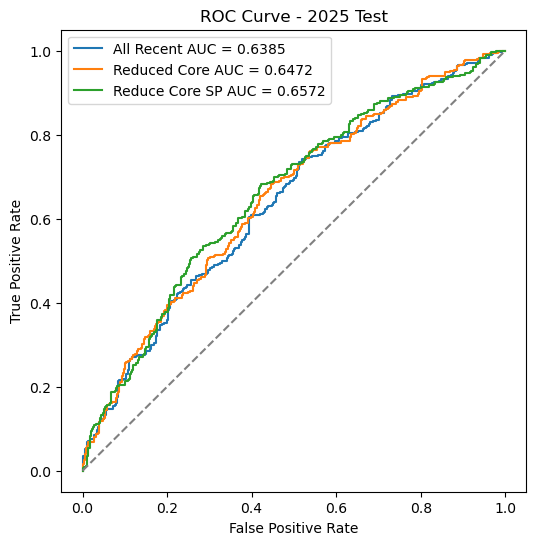


Use-case memo

This reduce-core SP model is intended for prediction before batting lineups are available.
It excludes lineup_OPS/OBP/SLG and top5 features, while retaining reduced-core starting-pitcher and recent team-flow signals.
Saved artifacts use the requested names: logit_model_reduce_core_sp and feature_cols_recent_reduce_core_sp.



In [43]:
# Reduced-core SP + recent-flow model
# Use this model when batting lineup features are unavailable.
# It keeps reduced-core starting pitcher signals and reduced-core recent team-flow signals.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

reduce_core_sp_features = [
    "sp_FIP_diff",
    "sp_ERA_diff",
    "sp_K9_diff",
    "sp_BB9_diff",
    "sp_HR9_diff",
    "sp_KBB_diff",
    "recent_10_win_rate_diff",
    "recent_5_run_diff_avg_diff",
    "recent_5_runs_against_avg_diff",
    "rest_days_diff",
    "prev_game_win_diff",
]
reduce_core_sp_features = [c for c in reduce_core_sp_features if c in model_input.columns]
missing_reduce_core_sp_features = [
    c for c in [
        "sp_FIP_diff",
        "sp_ERA_diff",
        "sp_K9_diff",
        "sp_BB9_diff",
        "sp_HR9_diff",
        "sp_KBB_diff",
        "recent_10_win_rate_diff",
        "recent_5_run_diff_avg_diff",
        "recent_5_runs_against_avg_diff",
        "rest_days_diff",
        "prev_game_win_diff",
    ]
    if c not in model_input.columns
]

print("=== reduce_core_sp_features ===")
print("feature count:", len(reduce_core_sp_features))
print(reduce_core_sp_features)
print("missing:", missing_reduce_core_sp_features)

recent_reduce_core_sp_cols = [
    c for c in reduce_core_sp_features
    if c.startswith("recent_") or c in ["rest_days_diff", "prev_game_win_diff"]
]

model_input_reduce_core_sp = model_input.copy()
model_input_reduce_core_sp[recent_reduce_core_sp_cols] = model_input_reduce_core_sp[recent_reduce_core_sp_cols].fillna(0)


def make_reduce_core_sp_model(C=1.0):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=C,
                    solver="lbfgs",
                    max_iter=5000,
                    random_state=427,
                ),
            ),
        ]
    )


def evaluate_reduce_core_sp_model(model_name, model, feature_cols, fit_df, eval_df):
    required_cols = feature_cols + ["y_home_win"]
    fit_ready = fit_df.dropna(subset=required_cols).copy()
    eval_ready = eval_df.dropna(subset=required_cols).copy()

    X_fit = fit_ready[feature_cols].copy()
    y_fit = fit_ready["y_home_win"].astype(int).copy()
    X_eval = eval_ready[feature_cols].copy()
    y_eval = eval_ready["y_home_win"].astype(int).copy()

    model.fit(X_fit, y_fit)

    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]
    lift_table_eval, _ = calculate_lift_table(y_eval, proba, n_bins=10)
    threshold_eval = evaluate_thresholds(y_eval.values, proba)

    high_065 = proba >= 0.65
    high_075 = proba >= 0.75
    high_080 = proba >= 0.80

    result = {
        "model": model_name,
        "train_seasons": ",".join(map(str, sorted(fit_ready["season"].unique()))),
        "test_season": ",".join(map(str, sorted(eval_ready["season"].unique()))),
        "n_train": len(fit_ready),
        "n_test": len(eval_ready),
        "n_features": len(feature_cols),
        "accuracy": accuracy_score(y_eval, pred),
        "auc": roc_auc_score(y_eval, proba),
        "brier": brier_score_loss(y_eval, proba),
        "top_decile_win_rate": lift_table_eval.loc[0, "actual_win_rate"],
        "top_decile_lift": lift_table_eval.loc[0, "lift"],
        "n_proba_ge_065": int(high_065.sum()),
        "win_rate_ge_065": y_eval[high_065].mean() if high_065.sum() > 0 else np.nan,
        "n_proba_ge_075": int(high_075.sum()),
        "win_rate_ge_075": y_eval[high_075].mean() if high_075.sum() > 0 else np.nan,
        "n_proba_ge_080": int(high_080.sum()),
        "win_rate_ge_080": y_eval[high_080].mean() if high_080.sum() > 0 else np.nan,
    }

    pred_df = eval_ready.copy()
    pred_df["y_true"] = y_eval.values
    pred_df["y_pred"] = pred
    pred_df["y_proba"] = proba
    pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"]).astype(int)

    return result, model, pred_df, lift_table_eval, threshold_eval


# Step 1: validation split, 2023 train -> 2024 test
train_2023_reduce_core_sp_df = model_input_reduce_core_sp[model_input_reduce_core_sp["season"] == 2023].copy()
test_2024_reduce_core_sp_df = model_input_reduce_core_sp[model_input_reduce_core_sp["season"] == 2024].copy()

reduce_core_sp_model_23_to_24 = make_reduce_core_sp_model(C=1.0)
(
    result_reduce_core_sp_23_to_24,
    reduce_core_sp_model_23_to_24,
    pred_2024_reduce_core_sp,
    lift_2024_reduce_core_sp,
    threshold_2024_reduce_core_sp,
) = evaluate_reduce_core_sp_model(
    model_name="reduce_core_sp_l2_C1_2023_train_2024_test",
    model=reduce_core_sp_model_23_to_24,
    feature_cols=reduce_core_sp_features,
    fit_df=train_2023_reduce_core_sp_df,
    eval_df=test_2024_reduce_core_sp_df,
)

# Step 2: final test split, 2023~2024 train -> 2025 test
train_2324_reduce_core_sp_df = model_input_reduce_core_sp[model_input_reduce_core_sp["season"] <= 2024].copy()
test_2025_reduce_core_sp_df = model_input_reduce_core_sp[model_input_reduce_core_sp["season"] == 2025].copy()

reduce_core_sp_model_2324_to_25 = make_reduce_core_sp_model(C=1.0)
(
    result_reduce_core_sp_2324_to_25,
    reduce_core_sp_model_2324_to_25,
    pred_2025_reduce_core_sp,
    lift_2025_reduce_core_sp,
    threshold_2025_reduce_core_sp,
) = evaluate_reduce_core_sp_model(
    model_name="reduce_core_sp_l2_C1_2023_2024_train_2025_test",
    model=reduce_core_sp_model_2324_to_25,
    feature_cols=reduce_core_sp_features,
    fit_df=train_2324_reduce_core_sp_df,
    eval_df=test_2025_reduce_core_sp_df,
)

reduce_core_sp_result = pd.DataFrame([result_reduce_core_sp_23_to_24, result_reduce_core_sp_2324_to_25])

print("\n=== reduce core SP model result ===")
display(reduce_core_sp_result.round(4))

print("\n=== 2025 lift table: reduce core SP model ===")
display(lift_2025_reduce_core_sp.round(4))

print("\n=== 2025 threshold evaluation: reduce core SP model ===")
display(threshold_2025_reduce_core_sp.round(4))

joblib.dump(reduce_core_sp_model_2324_to_25, "logit_model_reduce_core_sp.pkl")
joblib.dump(reduce_core_sp_features, "feature_cols_recent_reduce_core_sp.pkl")
print("\nsaved: logit_model_reduce_core_sp, feature_cols_recent_reduce_core_sp")

reduce_core_sp_coef_df = pd.DataFrame(
    {
        "feature": reduce_core_sp_features,
        "coefficient": reduce_core_sp_model_2324_to_25.named_steps["model"].coef_[0],
    }
)
reduce_core_sp_coef_df["abs_coefficient"] = reduce_core_sp_coef_df["coefficient"].abs()
reduce_core_sp_coef_df = reduce_core_sp_coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print("\n=== reduce core SP coefficients ===")
display(reduce_core_sp_coef_df.round(4))

reduce_core_sp_y_true = pred_2025_reduce_core_sp["y_true"].astype(int).values
reduce_core_sp_y_proba = pred_2025_reduce_core_sp["y_proba"].astype(float).values
reduce_core_sp_fpr, reduce_core_sp_tpr, _ = roc_curve(reduce_core_sp_y_true, reduce_core_sp_y_proba)
reduce_core_sp_auc = roc_auc_score(reduce_core_sp_y_true, reduce_core_sp_y_proba)

plt.figure(figsize=(6, 6))
if "y_test" in globals() and "y_test_proba" in globals():
    recent_fpr, recent_tpr, _ = roc_curve(y_test, y_test_proba)
    recent_auc = roc_auc_score(y_test, y_test_proba)
    plt.plot(recent_fpr, recent_tpr, label=f"All Recent AUC = {recent_auc:.4f}")
if "reduced_core_y_true" in globals() and "reduced_core_y_proba" in globals():
    reduced_fpr, reduced_tpr, _ = roc_curve(reduced_core_y_true, reduced_core_y_proba)
    reduced_auc = roc_auc_score(reduced_core_y_true, reduced_core_y_proba)
    plt.plot(reduced_fpr, reduced_tpr, label=f"Reduced Core AUC = {reduced_auc:.4f}")
plt.plot(reduce_core_sp_fpr, reduce_core_sp_tpr, label=f"Reduce Core SP AUC = {reduce_core_sp_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 2025 Test")
plt.legend()
plt.show()

print(
    """
Use-case memo

This reduce-core SP model is intended for prediction before batting lineups are available.
It excludes lineup_OPS/OBP/SLG and top5 features, while retaining reduced-core starting-pitcher and recent team-flow signals.
Saved artifacts use the requested names: logit_model_reduce_core_sp and feature_cols_recent_reduce_core_sp.
"""
)